# Homework 4 — U-Net Training

`smp.Unet(encoder_name='efficientnet-b0', encoder_weights='imagenet')` with
**BCE + Dice** loss. 30 epochs, save best by validation Dice.

In [1]:
import os, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}   smp: {smp.__version__}")
torch.manual_seed(0); np.random.seed(0); random.seed(0)

Device: cuda   smp: 0.5.0


## 1. Dataset + augmentations

In [2]:
ROOT = "datasets/bbbc010_seg"
MEAN = [0.485, 0.456, 0.406]; STD = [0.229, 0.224, 0.225]

train_tf = A.Compose([
    # TODONE (Ex 2): geometric augmentations, all with p=0.5
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])
eval_tf = A.Compose([A.Normalize(mean=MEAN, std=STD), ToTensorV2()])

class WormDataset(Dataset):
    def __init__(self, split, transform):
        self.img_dir  = os.path.join(ROOT, split, "images")
        self.mask_dir = os.path.join(ROOT, split, "masks")
        self.files = sorted(os.listdir(self.img_dir))
        self.transform = transform
    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        f = self.files[i]
        img  = np.array(Image.open(os.path.join(self.img_dir,  f)).convert("RGB"))
        mask = np.array(Image.open(os.path.join(self.mask_dir, f)).convert("L")) // 255
        out = self.transform(image=img, mask=mask)
        return out["image"], out["mask"].unsqueeze(0).float()

train_ds = WormDataset("train", train_tf)
val_ds   = WormDataset("test",  eval_tf)
print(f"train={len(train_ds)}  val={len(val_ds)}")

BATCH = 4
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

train=80  val=20


## 2. Model + loss

In [ ]:
# TODONE (Ex 2): EfficientNet-B0 backbone, ImageNet weights, 3-channel input, 1-class output
model = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(device)
print(f"Params: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")

bce  = nn.BCEWithLogitsLoss()
dice = smp.losses.DiceLoss(mode="binary")
# TODONE (Ex 2): combined loss = equal-weight mix of BCE and Dice
def loss_fn(logits, y): return 0.5 * bce(logits, y) + 0.5 * dice(logits, y)

@torch.no_grad()
def dice_iou(logits, y, thr=0.5):
    # TODONE (Ex 2): apply sigmoid, then threshold at thr
    pred = (torch.sigmoid(logits) > thr).long()
    tp, fp, fn, tn = smp.metrics.get_stats(pred, y.long(), mode="binary")
    return (smp.metrics.f1_score(tp, fp, fn, tn, reduction="micro").item(),
            smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro").item())

Params: 6.25 M


## 3. Training loop (30 epochs, save best by val Dice)

In [ ]:
# TODONE (Ex 2): 30 epochs; Adam LR 1e-4 for fine-tuning a pretrained encoder
EPOCHS = 30
LR = 1e-4
CKPT = "checkpoints/unet_efficientnet-b0.pt"
os.makedirs(os.path.dirname(CKPT), exist_ok=True)

opt = torch.optim.Adam(model.parameters(), lr=LR)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}
best = -1.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    tr_losses = []
    pbar = tqdm(train_loader, desc=f"epoch {epoch}/{EPOCHS}", leave=False)
    for x, y in pbar:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        opt.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward(); opt.step()
        tr_losses.append(loss.item())
        pbar.set_postfix(loss=f"{loss.item():.3f}")
    sched.step()

    model.eval()
    vl, vd, vi = [], [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            vl.append(loss_fn(logits, y).item())
            d, i = dice_iou(logits, y); vd.append(d); vi.append(i)
    tr_mean = float(np.mean(tr_losses)); vl_mean = float(np.mean(vl))
    vd_mean = float(np.mean(vd));        vi_mean = float(np.mean(vi))
    history["train_loss"].append(tr_mean); history["val_loss"].append(vl_mean)
    history["val_dice"].append(vd_mean);   history["val_iou"].append(vi_mean)

    flag = ""
    if vd_mean > best:
        best = vd_mean
        torch.save({"model": model.state_dict(), "epoch": epoch, "val_dice": vd_mean}, CKPT)
        flag = "  ★ new best"
    print(f"epoch {epoch:02d}  train={tr_mean:.3f}  val={vl_mean:.3f}  "
          f"dice={vd_mean:.3f}  iou={vi_mean:.3f}{flag}")

print(f"\nBest val Dice = {best:.4f}  →  {CKPT}")

epoch 01  train=0.946  val=1.224  dice=0.078  iou=0.041  ★ new best


epoch 02  train=0.825  val=1.031  dice=0.087  iou=0.045  ★ new best


epoch 03  train=0.756  val=0.892  dice=0.098  iou=0.052  ★ new best


epoch 04  train=0.711  val=0.832  dice=0.104  iou=0.055  ★ new best


epoch 05  train=0.680  val=0.802  dice=0.109  iou=0.057  ★ new best


...

epoch 26  train=0.506  val=0.621  dice=0.850  iou=0.739


epoch 27  train=0.505  val=0.618  dice=0.851  iou=0.742  ★ new best


epoch 28  train=0.504  val=0.617  dice=0.854  iou=0.745  ★ new best


epoch 29  train=0.504  val=0.616  dice=0.854  iou=0.746  ★ new best


epoch 30  train=0.504  val=0.613  dice=0.857  iou=0.750  ★ new best

Best val Dice = 0.8568  →  checkpoints/unet_efficientnet-b0.pt


## 4. Training curves

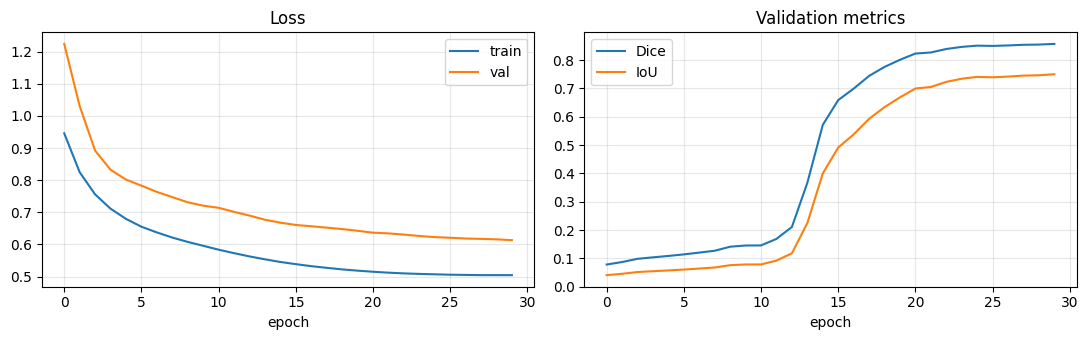

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(history["val_dice"], label="Dice"); ax[1].plot(history["val_iou"], label="IoU")
ax[1].set_title("Validation metrics"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Conclusion

Best checkpoint saved. Move on to `02_Evaluation.ipynb`.

# Experiment using gaussian noise in training

In [ ]:
ROOT = "datasets/bbbc010_seg"
MEAN = [0.485, 0.456, 0.406]; STD = [0.229, 0.224, 0.225]

train_tf = A.Compose([
    # TODONE (Ex 2): geometric augmentations, all with p=0.5
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),
    A.GaussNoise(std_range=(0.001, 0.02), p=0.5),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])
eval_tf = A.Compose([A.Normalize(mean=MEAN, std=STD), ToTensorV2()])

class WormDataset(Dataset):
    def __init__(self, split, transform):
        self.img_dir  = os.path.join(ROOT, split, "images")
        self.mask_dir = os.path.join(ROOT, split, "masks")
        self.files = sorted(os.listdir(self.img_dir))
        self.transform = transform
    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        f = self.files[i]
        img  = np.array(Image.open(os.path.join(self.img_dir,  f)).convert("RGB"))
        mask = np.array(Image.open(os.path.join(self.mask_dir, f)).convert("L")) // 255
        out = self.transform(image=img, mask=mask)
        return out["image"], out["mask"].unsqueeze(0).float()

train_ds = WormDataset("train", train_tf)
val_ds   = WormDataset("test",  eval_tf)
print(f"train={len(train_ds)}  val={len(val_ds)}")

BATCH = 4
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

train=80  val=20


In [14]:
# TODONE (Ex 2): 30 epochs; Adam LR 1e-4 for fine-tuning a pretrained encoder
EPOCHS = 30
LR = 1e-4
CKPT = "checkpoints/unet_wG_efficientnet-b0.pt"
os.makedirs(os.path.dirname(CKPT), exist_ok=True)

def loss_fn(logits, y): return 0.5 * bce(logits, y) + 0.5 * dice(logits, y)


model = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(device)
print(f"Params: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")

opt = torch.optim.Adam(model.parameters(), lr=LR)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}
best = -1.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    tr_losses = []
    pbar = tqdm(train_loader, desc=f"epoch {epoch}/{EPOCHS}", leave=False)
    for x, y in pbar:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        opt.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward(); opt.step()
        tr_losses.append(loss.item())
        pbar.set_postfix(loss=f"{loss.item():.3f}")
    sched.step()

    model.eval()
    vl, vd, vi = [], [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            vl.append(loss_fn(logits, y).item())
            d, i = dice_iou(logits, y); vd.append(d); vi.append(i)
    tr_mean = float(np.mean(tr_losses)); vl_mean = float(np.mean(vl))
    vd_mean = float(np.mean(vd));        vi_mean = float(np.mean(vi))
    history["train_loss"].append(tr_mean); history["val_loss"].append(vl_mean)
    history["val_dice"].append(vd_mean);   history["val_iou"].append(vi_mean)

    flag = ""
    if vd_mean > best:
        best = vd_mean
        torch.save({"model": model.state_dict(), "epoch": epoch, "val_dice": vd_mean}, CKPT)
        flag = "  ★ new best"
    print(f"epoch {epoch:02d}  train={tr_mean:.3f}  val={vl_mean:.3f}  "
          f"dice={vd_mean:.3f}  iou={vi_mean:.3f}{flag}")

print(f"\nBest val Dice = {best:.4f}  →  {CKPT}")

Params: 6.25 M


epoch 01  train=0.775  val=0.710  dice=0.343  iou=0.207  ★ new best


epoch 02  train=0.691  val=0.620  dice=0.516  iou=0.348  ★ new best


epoch 03  train=0.627  val=0.567  dice=0.617  iou=0.446  ★ new best


epoch 04  train=0.579  val=0.521  dice=0.754  iou=0.606  ★ new best


...

epoch 26  train=0.303  val=0.306  dice=0.866  iou=0.764


epoch 27  train=0.303  val=0.305  dice=0.866  iou=0.763


epoch 28  train=0.302  val=0.305  dice=0.866  iou=0.764


epoch 29  train=0.302  val=0.305  dice=0.866  iou=0.764


epoch 30  train=0.302  val=0.305  dice=0.866  iou=0.764

Best val Dice = 0.8664  →  checkpoints/unet_wG_efficientnet-b0.pt
